<a href="https://colab.research.google.com/github/RafayRizwan023/Deep_Learning_Labs_Raf023/blob/main/Lab%2303/Lab3_MNIST_DATA_Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [2]:
# Step 1: Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # Load the dataset

# Normalize the pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0  # Scale training data
x_test = x_test.astype('float32') / 255.0  # Scale test data

# One-hot encode the labels (0-9) for categorical classification
y_train = to_categorical(y_train, 10)  # Encode training labels
y_test = to_categorical(y_test, 10)  # Encode test labels

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# ***With ADAM optimizer***

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9335 - loss: 0.2176 - val_accuracy: 0.9619 - val_loss: 0.1258
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9704 - loss: 0.0947 - val_accuracy: 0.9660 - val_loss: 0.1075
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9802 - loss: 0.0649 - val_accuracy: 0.9715 - val_loss: 0.0932
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9840 - loss: 0.0497 - val_accuracy: 0.9712 - val_loss: 0.0966
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9872 - loss: 0.0403 - val_accuracy: 0.9712 - val_loss: 0.1070
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9890 - loss: 0.0334 - val_accuracy: 0.9760 - val_loss: 0.0921
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9904 - loss: 0.0281 - val_accuracy: 0.9759 - val_loss: 0.1071
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9924 - loss: 0.0236 - 

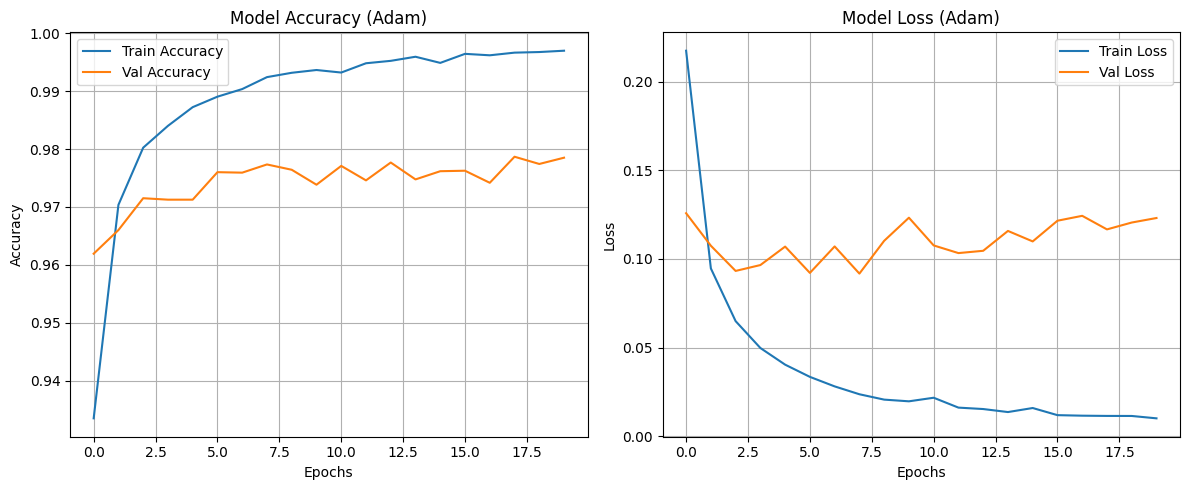

In [3]:
# ---------------- Model v1: Adam ----------------
model_v1 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='selu'),
    Dense(10, activation='softmax')
])
model_v1.summary()

model_v1.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_v1 = model_v1.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
test_loss_v1, test_acc_v1 = model_v1.evaluate(x_test, y_test)
print(f"[Adam] Test Accuracy: {test_acc_v1:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v1.history['accuracy'], label='Train Accuracy')
plt.plot(history_v1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (Adam)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Adam)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid()
plt.tight_layout(); plt.show()


Reaching 100% training accuracy means the model correctly classified all training samples, which can be a sign of overfitting. However, it does not always mean the model is bad. Here, validation accuracy stayed around 98.1% and validation loss remained stable, so the model still generalized well.

# ***SGD optimizer***

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9212 - loss: 0.2570 - val_accuracy: 0.9591 - val_loss: 0.1378
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9675 - loss: 0.1071 - val_accuracy: 0.9632 - val_loss: 0.1150
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9769 - loss: 0.0715 - val_accuracy: 0.9719 - val_loss: 0.0932
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9827 - loss: 0.0529 - val_accuracy: 0.9705 - val_loss: 0.1036
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9881 - loss: 0.0360 - val_accuracy: 0.9724 - val_loss: 0.0994
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9914 - loss: 0.0263 - val_accuracy: 0.9743 - val_loss: 0.0999
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9943 - loss: 0.0182 - val_accuracy: 0.9765 - val_loss: 0.0978
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9960 - loss: 0.0125 - 

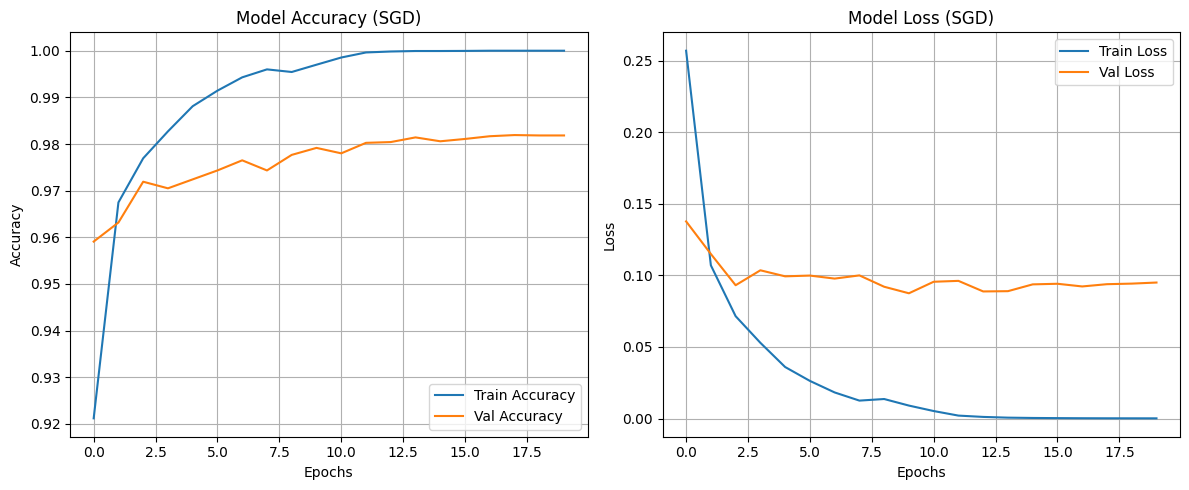

In [4]:
model_v2 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='selu'),
    Dense(10, activation='softmax')
])
model_v2.summary()

model_v2.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy', metrics=['accuracy'])
history_v2 = model_v2.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
test_loss_v2, test_acc_v2 = model_v2.evaluate(x_test, y_test)
print(f"[SGD] Test Accuracy: {test_acc_v2:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (SGD)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Val Loss')
plt.title('Model Loss (SGD)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid()
plt.tight_layout(); plt.show()


# ***RMSprop***

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9313 - loss: 0.2260 - val_accuracy: 0.9676 - val_loss: 0.1078
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9711 - loss: 0.0988 - val_accuracy: 0.9637 - val_loss: 0.1237
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9792 - loss: 0.0694 - val_accuracy: 0.9752 - val_loss: 0.0921
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9840 - loss: 0.0541 - val_accuracy: 0.9758 - val_loss: 0.0981
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9875 - loss: 0.0432 - val_accuracy: 0.9743 - val_loss: 0.1097
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9902 - loss: 0.0342 - val_accuracy: 0.9728 - val_loss: 0.1305
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9919 - loss: 0.0287 - val_accuracy: 0.9760 - val_loss: 0.1198
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9927 - loss: 0.0238 - 

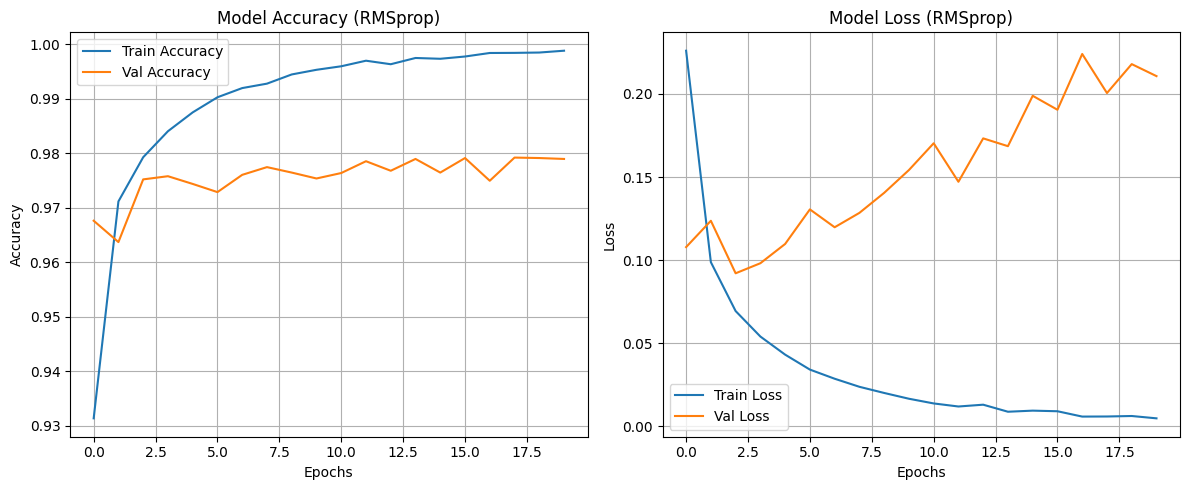

In [5]:
model_v3 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='selu'),
    Dense(10, activation='softmax')
])
model_v3.summary()

model_v3.compile(optimizer=RMSprop(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
history_v3 = model_v3.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
test_loss_v3, test_acc_v3 = model_v3.evaluate(x_test, y_test)
print(f"[RMSprop] Test Accuracy: {test_acc_v3:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v3.history['accuracy'], label='Train Accuracy')
plt.plot(history_v3.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (RMSprop)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_v3.history['loss'], label='Train Loss')
plt.plot(history_v3.history['val_loss'], label='Val Loss')
plt.title('Model Loss (RMSprop)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid()
plt.tight_layout(); plt.show()

Validation accuracy stabilized around 98.1–98.2%, while validation loss stayed almost flat at around 0.09–0.10. Even though the training accuracy reached 100%, there was no clear increase in validation loss, which suggests that the model was not overfitting significantly.

Validation accuracy reached around 97.8% and then started to decrease slightly. At the same time, validation loss increased from about 0.10 to 0.16, while the training loss continued approaching zero.

Validation accuracy stayed around 97.9%, but validation loss increased more noticeably from about 0.10 to 0.21. This happened even though the training loss became very low (around 0.007), indicating that the model was fitting the training data too closely.


Overfitting usually happens when training loss keeps decreasing while validation loss starts increasing. In our results, this happened more with Adam and RMSprop, while SGD maintained stable validation performance even after reaching 100% training accuracy.